12MAR26

# QAOA for Partnumber A — Daily Storage (5€/unit/day) & Lost Sales (3€/unit/day)

This notebook instantiates a **QAOA** optimization model for **Partnumber A** with:

- **Holding (storage) cost**: `C_hold = 5.0 €` per unit per **day**.
- **Lost sales penalty**: `C_lost = 3.0 €` **per unmet unit per day** (if demand is not fully met).
- **Demand**: either deterministic (mean 5/day) **or** scenario-averaged with samples from a truncated Normal distribution (mean 5, sigma 3, min 0). Use the toggle below.
- **Procurement**: binary order `o_t ∈ {0,1}` per day that, if 1, brings a **fixed lot** of `Q_lot` units.

Encode a QUBO and map to an **Ising** `SparsePauliOp`, then train a **QAOA** ansatz (Qiskit 2.x V2 primitives: `StatevectorEstimator`/`StatevectorSampler`).

In [ ]:
# export to a script (optional)
#!jupyter nbconvert --to script QAOA_TLS_V2.ipynb

# Part A — Classical baseline (Brute Force no Optimization)

### Decision Variables

For each day \(t = 1, \dots, T\):

- \(o_t \in \{0, 1\}\)  
  - \(o_t = 1\): place an order  
  - \(o_t = 0\): do not order  

Each order delivers a fixed lot of \(Q_{\text{lot}}\) units.
``

### Inventory Dynamics

Let:
- \(I_t\): inventory at the beginning of day \(t\)
- \(I_0\): initial inventory
- \(D_t\): demand on day \(t\)
- \(Q_{\text{lot}}\): replenishment lot size

Inventory after fulfilling demand:

\[
I_{t+1} = \max(0,\; I_t + o_t Q_{\text{lot}} - D_t)
\]

### Lost Sales

Define the shortage on day \(t\):

\[
L_t = \max(0,\; D_t - (I_t + o_t Q_{\text{lot}}))
\]

If inventory plus incoming deliveries is insufficient to meet demand,  
the difference is counted as lost sales.

### Daily Cost Function

Costs consist of:

- Holding cost: \(C_{\text{hold}}\) per unit carried to the next day  
- Lost-sales penalty: \(C_{\text{lost}}\) per unmet demand unit  

For each day \(t\):

\[
C_t = C_{\text{hold}} \cdot I_{t+1}
     + C_{\text{lost}} \cdot L_t
\]

### Total Cost for an Order Sequence

Given a binary ordering policy
\[
\mathbf{o} = (o_1, o_2, \ldots, o_T),
\]
the total cost is:

\[
C(\mathbf{o}) =
\sum_{t=1}^{T}
\left[
C_{\text{hold}} \cdot \max(0,\; I_t + o_t Q_{\text{lot}} - D_t)
+
C_{\text{lost}} \cdot \max(0,\; D_t - (I_t + o_t Q_{\text{lot}}))
\right]
\]

where inventories evolve according to:

\[
I_{t+1} = \max(0,\; I_t + o_t Q_{\text{lot}} - D_t)
\]
with \(I_0\) given.

### Complete Brute-Force Optimization Problem

\[
\boxed{
\begin{aligned}
\min_{o_t \in \{0,1\}}
\quad
&\sum_{t=1}^T 
\left[
C_{\text{hold}}
\cdot
\max\left(0,\; I_t + o_t Q_{\text{lot}} - D_t \right)
+
C_{\text{lost}}
\cdot
\max\left(0,\; D_t - (I_t + o_t Q_{\text{lot}})\right)
\right]
\\[6pt]
\text{s.t.} \quad
&I_{t+1} = \max\left(0,\; I_t + o_t Q_{\text{lot}} - D_t\right),
\quad t = 0,\dots,T-1
\\
&I_0\ \text{given}
\end{aligned}
}
\]

In [1]:
# Problem parameters
T = 5                 # number of days
Q_lot = 10            # lot size
C_hold = 5.0          # holding cost per unit
C_lost = 3.0          # lost sales penalty
I0 = 5                # initial inventory

# Demand scenario (could also sample from N(5,3))
D = [5, 6, 4, 7, 5]

In [2]:
import itertools
import numpy as np



def evaluate(order_seq):
    I = I0
    total_cost = 0
    for t, o in enumerate(order_seq):
        incoming = o * Q_lot
        demand = D[t]

        if I + incoming >= demand:
            I_next = I + incoming - demand
            lost = 0
        else:
            I_next = 0
            lost = demand - (I + incoming)

        cost = C_hold * I_next + C_lost * lost
        total_cost += cost
        I = I_next

    return total_cost


best_cost = float("inf")
best_seq = None

for seq in itertools.product([0,1], repeat=T):
    cost = evaluate(seq)
    if cost < best_cost:
        best_cost = cost
        best_seq = seq

print("Best ordering policy:", best_seq)
print("Minimum cost:", best_cost)

Best ordering policy: (0, 1, 0, 1, 0)
Minimum cost: 41.0


| Day | Decision o_t | Meaning        |
|-----|--------------|----------------|
| 1   | 0            | Do not order   |
| 2   | 1            | Order 1 lot    |
| 3   | 0            | Do not order   |
| 4   | 1            | Order 1 lot    |
| 5   | 0            | Do not order   |

-> The optimal policy is to order on Day 2 and Day 4.

## Minimum cost

41.0 €

This is the lowest total 5‑day cost among all 32 possible order sequences (because 2^5=32).

## Why is this optimal

- Ordering too early → high holding costs (5 €/unit/day)
- Ordering too late → shortages with penalty (3 €/unit)
- Demand is moderate (≈5–7/day)
- Initial inventory is small (5 units)
- Lot size is large (10 units)

## The sequence (0,1,0,1,0):

- avoids building large inventory early
- replenishes right before demand peaks
- prevents lost-sales penalties later
- minimizes both holding and shortage costs

# What brute force does:

1. Enumerates all 2^T order sequences (T = 5 → 32 sequences)
2. Simulates inventory movement for each:
   - inventory after each day
   - demand vs. supply
   - lost-sales
   - holding cost
   - lost-sales penalty
3. Computes total cost for each sequence
4. Picks the sequence with the lowest cost

So the result:

Best ordering policy: (0, 1, 0, 1, 0)

Minimum cost: 41.0

👉 This is the globally optimal solution.

👉 No other ordering pattern yields a lower 5‑day total cost.

Here’s the **complete 5‑day brute‑force cost calculation** for the policy  
`(0, 1, 0, 1, 0)` — **entirely in Markdown** so you can paste it into a README or notebook.

***

# **Parameters**

*   Initial inventory: $$I_0 = 5$$
*   Lot size: $$Q_{\text{lot}} = 10$$
*   Holding cost: $$C_{\text{hold}} = 5$$ €/unit/day
*   Lost‑sales penalty: $$C_{\text{lost}} = 3$$ €/unit
*   Demand scenario: $$D = [5, 6, 4, 7, 5]$$
*   Ordering policy: $$\mathbf{o} = (0, 1, 0, 1, 0)$$

**Inventory dynamics and costs per day**

$$
\begin{aligned}
I_{t+1} &= \max\!\left(0,\; I_t + o_t Q_{\text{lot}} - D_t\right) \\
L_t &= \max\!\left(0,\; D_t - (I_t + o_t Q_{\text{lot}})\right) \\
C_t &= C_{\text{hold}} \cdot I_{t+1} + C_{\text{lost}} \cdot L_t
\end{aligned}
$$

***

## **Day 1**

*   Decision: $$o_1 = 0$$ (no order)
*   Demand: $$D_1 = 5$$
*   Start inventory: $$I_0 = 5$$

**Calculations**

$$
\begin{aligned}
\text{Available} &= I_0 + o_1 Q_{\text{lot}} = 5 + 0 = 5 \\
I_1 &= \max(0, 5 - 5) = 0 \\
L_1 &= \max(0, 5 - 5) = 0 \\
C_1 &= 5 \cdot 0 + 3 \cdot 0 = \mathbf{0}
\end{aligned}
$$

***

## **Day 2**

*   Decision: $$o_2 = 1$$ (order 10 units)
*   Demand: $$D_2 = 6$$
*   Start inventory: $$I_1 = 0$$

**Calculations**

$$
\begin{aligned}
\text{Available} &= 0 + 10 = 10 \\
I_2 &= \max(0, 10 - 6) = 4 \\
L_2 &= \max(0, 6 - 10) = 0 \\
C_2 &= 5 \cdot 4 + 3 \cdot 0 = \mathbf{20}
\end{aligned}
$$

***

## **Day 3**

*   Decision: $$o_3 = 0$$ (no order)
*   Demand: $$D_3 = 4$$
*   Start inventory: $$I_2 = 4$$

**Calculations**

$$
\begin{aligned}
\text{Available} &= 4 \\
I_3 &= \max(0, 4 - 4) = 0 \\
L_3 &= \max(0, 4 - 4) = 0 \\
C_3 &= 5 \cdot 0 + 3 \cdot 0 = \mathbf{0}
\end{aligned}
$$

***

## **Day 4**

*   Decision: $$o_4 = 1$$ (order 10 units)
*   Demand: $$D_4 = 7$$
*   Start inventory: $$I_3 = 0$$

**Calculations**

$$
\begin{aligned}
\text{Available} &= 0 + 10 = 10 \\
I_4 &= \max(0, 10 - 7) = 3 \\
L_4 &= \max(0, 7 - 10) = 0 \\
C_4 &= 5 \cdot 3 + 3 \cdot 0 = \mathbf{15}
\end{aligned}
$$

***

## **Day 5**

*   Decision: $$o_5 = 0$$ (no order)
*   Demand: $$D_5 = 5$$
*   Start inventory: $$I_4 = 3$$

**Calculations**

$$
\begin{aligned}
\text{Available} &= 3 \\
I_5 &= \max(0, 3 - 5) = 0 \\
L_5 &= \max(0, 5 - 3) = 2 \\
C_5 &= 5 \cdot 0 + 3 \cdot 2 = \mathbf{6}
\end{aligned}
$$

***

## **Summary Table**

| Day | $$o_t$$ | Start Inv | Order | Demand | End Inv $$I_{t+1}$$ | Lost Sales $$L_t$$ | Cost $$C_t$$ |
| --- | ------- | --------- | ----- | ------ | ------------------- | ------------------ | ------------ |
| 1   | 0       | 5         | 0     | 5      | 0                   | 0                  | 0 €          |
| 2   | 1       | 0         | 10    | 6      | 4                   | 0                  | 20 €         |
| 3   | 0       | 4         | 0     | 4      | 0                   | 0                  | 0 €          |
| 4   | 1       | 0         | 10    | 7      | 3                   | 0                  | 15 €         |
| 5   | 0       | 3         | 0     | 5      | 0                   | 2                  | 6 €          |

**Total cost**

$$
C_{\text{total}} = C_1 + C_2 + C_3 + C_4 + C_5 = 0 + 20 + 0 + 15 + 6 = \boxed{41\ \text{€}}
$$

# Part B — Quantum Optimization

### 1. Transformation for Quantum

Import required packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import transpile, QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

# Aer tensor-network backend (fast + memory safe)
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator, SamplerV2 as AerSampler

print("Imports OK.")

Imports OK.


### Define the cost_hamiltonian
Constructing a quantum operator H that produces the same numerical value as your classical inventory cost for every policy.

In [4]:
import numpy as np
from typing import Tuple, List

# --- Your classical simulator (same dynamics you already use) ---
def simulate_cost(order_seq: Tuple[int, ...], Q_lot, C_hold, C_lost, I0, D) -> float:
    I = I0
    total = 0.0
    for t, o in enumerate(order_seq):
        incoming = o * Q_lot
        demand = D[t]
        available = I + incoming
        if available >= demand:
            I_next = available - demand
            lost = 0
        else:
            I_next = 0
            lost = demand - available
        cost = C_hold * I_next + C_lost * lost
        total += cost
        I = I_next
    return total

def _bits_of_int(x: int, n: int) -> Tuple[int, ...]:
    return tuple((x >> i) & 1 for i in range(n))  # q0..q{n-1}

def build_full_cost_hamiltonian(
    T: int,
    Q_lot: int,
    C_hold: float,
    C_lost: float,
    I0: int,
    D: List[int],
    prune_tol: float = 1e-10,
) -> Tuple[SparsePauliOp, float]:
    """
    Returns (H, offset) such that for any policy o ∈ {0,1}^T,
    ⟨o| H |o⟩ + offset == simulate_cost(o, ...), exactly (up to prune_tol).
    """
    n = T
    N = 1 << n

    # Tabulate classical cost f(x) for all bitstrings x
    f = np.zeros(N, dtype=float)
    for x in range(N):
        o = _bits_of_int(x, n)
        f[x] = simulate_cost(o, Q_lot, C_hold, C_lost, I0, D)

    # Fast Walsh–Hadamard Transform (coeff[S] = 2^{-n} ∑_x f(x) (-1)^{x·S})
    coeff = f.copy()
    len_ = 1
    while len_ < N:
        for i in range(0, N, 2*len_):
            for j in range(i, i+len_):
                u, v = coeff[j], coeff[j+len_]
                coeff[j] = u + v
                coeff[j+len_] = u - v
        len_ *= 2
    coeff /= N

    # Build Pauli strings for all non-zero subsets S
    paulis, weights = [], []
    offset = float(coeff[0])  # constant
    for S in range(1, N):
        cS = float(coeff[S])
        if abs(cS) < prune_tol:
            continue
        # 'Z' on qubits where S has a 1-bit, else 'I' (q0..q{n-1})
        chars = ['I'] * n
        for i in range(n):
            if (S >> i) & 1:
                chars[i] = 'Z'
        paulis.append(''.join(chars))
        weights.append(cS)

    H = SparsePauliOp(paulis, weights) if paulis else SparsePauliOp(["I"*n], [0.0])
    return H, offset

### Generate Hamiltonian (cost_hamiltonian) from the concrete problem: 

In [7]:
full_cost_hamiltonian, offset = build_full_cost_hamiltonian(
    T, Q_lot, C_hold, C_lost, I0, D
)

In [33]:
reps = 5 # Higher reps = more expressive quantum circuit.

In [34]:
# Aer MPS backend
aer_backend = AerSimulator(method="matrix_product_state")

# QAOA ansatz
ansatz = QAOAAnsatz(cost_operator=full_cost_hamiltonian, reps=reps)
print("Ansatz:", ansatz.num_qubits, "qubits;", len(ansatz.parameters), "params")

# Transpile for Aer
isa_ansatz = transpile(ansatz, backend=aer_backend, optimization_level=1)
print("Transpiled circuit qubits:", isa_ansatz.num_qubits)

Ansatz: 5 qubits; 10 params
Transpiled circuit qubits: 5


In [35]:
# ===========================================================
# OBJECTIVE (EstimatorV2) — includes offset and angle wrapping
# ===========================================================
estimator = AerEstimator.from_backend(aer_backend)
# Optional smoothing (if you are sampling, not statevector):
# estimator.options.run_options.shots = 20_000

trace = []

# Cache observable under layout (you already did this correctly)
isa_obs = full_cost_hamiltonian.apply_layout(isa_ansatz.layout)

# IMPORTANT: use the transpiled circuit's parameter list
n_params = len(isa_ansatz.parameters)

# Initial random parameters in [0, 2π)
params0 = np.random.uniform(0, 2*np.pi, size=n_params)

def objective(theta):
    # Enforce periodicity (COBYLA is unconstrained)
    theta = np.mod(theta, 2*np.pi)

    # EstimatorV2 expects a tuple: (circuit, observables, parameter_values)
    # Here we provide a single pub in a list.
    pub = (isa_ansatz, isa_obs, [theta])

    # Expectation value <H>
    ev = estimator.run([pub]).result()[0].data.evs[0]

    # Add the constant offset so we optimize actual cost
    cost = ev + offset

    trace.append(cost)
    return cost

print("Objective ready.")

Objective ready.


 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 148.33002321051228
       x: [ 7.637e-01  5.037e+00  5.742e+00  2.784e+00  4.719e+00
            5.125e+00  4.335e+00  5.262e+00  1.192e-01  1.572e+00]
    nfev: 55
   maxcv: 0.0


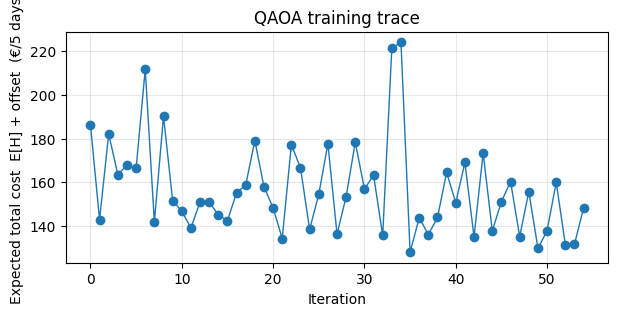

Optimization complete. Best cost estimate: 148.33002321051228


In [36]:
# ===========================================================
# OPTIMIZATION
# ===========================================================
from scipy.optimize import minimize
import matplotlib.pyplot as plt

res = minimize(
    objective,
    params0,
    method="COBYLA",
    tol=1e-2,
    options={"maxiter": 250, "rhobeg": 0.5}  # rhobeg ~ step size; tweak as needed
)

print(res)

plt.figure(figsize=(7,3))
plt.plot(trace, marker="o", lw=1)
plt.xlabel("Iteration")
plt.ylabel("Expected total cost  E[H] + offset  (€/5 days)")
plt.title("QAOA training trace")
plt.grid(alpha=0.3)
plt.show()

opt_params = np.mod(res.x, 2*np.pi)  # store wrapped optimal angles
print("Optimization complete. Best cost estimate:", trace[-1])

### Calculate Bitsring using sampler Primitive

In [37]:
# Make sure these are defined earlier:
# - aer_backend         (AerSimulator)
# - isa_ansatz          (transpiled ansatz)
# - opt_params          (optimized parameter vector)
# - full_cost_hamiltonian / offset (for earlier steps; not needed for sampling)
# - IMPORTANT: N_VARS (number of logical qubits) equals isa_ansatz.num_qubits

N_VARS = isa_ansatz.num_qubits  # ensure consistency

# Create a parameter-bound circuit (no free params)
opt_circ = isa_ansatz.assign_parameters(opt_params, inplace=False)

# Add classical register and measurements (one shot per logical qubit)
cl = ClassicalRegister(N_VARS, name="out")
qc = QuantumCircuit(opt_circ.num_qubits, name="qaoa_opt")
qc.compose(opt_circ, inplace=True)
qc.add_register(cl)

# Measure qubits q0..q{N_VARS-1} into classical bits c0..c{N_VARS-1}
# (This produces bitstrings in little-endian order: c0 is LSB)
qc.measure(range(N_VARS), cl)

# SamplerV2: for measured, parameter-free circuits, pass just the circuit objects
sampler = AerSampler.from_backend(aer_backend)
job = sampler.run([qc], shots=4096)
res = job.result()[0]

# Access counts from SamplerV2 result
counts = res.data.out.get_counts()  # not .meas, no index needed

# Normalize to probabilities and pick the mode
shots = sum(counts.values())
probs = {bit: ct / shots for bit, ct in counts.items()}
best_bitstring = max(probs.items(), key=lambda kv: kv[1])[0]

#print("Most likely bitstring (raw):", best_bitstring)

# If you want policy as (o1,...,oT) with q0=Day1 etc., convert endianness:
# Sampler returns strings with c_{N-1} ... c_0 (MSB...LSB) typical printing.
# If you measured q[i] -> c[i] as above, then reverse to map to (q0,...,q{N-1}).
policy = tuple(int(b) for b in best_bitstring[::-1])

#print("Policy (q0..q{N-1}):", policy)

In [38]:
print("Most likely bitstring (raw):", best_bitstring)
print("Policy (q0..q{N-1}):", policy)

Most likely bitstring (raw): 00111
Policy (q0..q{N-1}): (1, 1, 1, 0, 0)


# Next iteration with different (better) parameters for optimization

In [39]:
# Instance parameters (adjust only if you change the problem)
Q_lot = 10
C_hold = 5.0
C_lost = 3.0
I0 = 5
D = [5, 6, 4, 7, 5]

# Classical cost simulator (parameterized)
def simulate_cost(policy, Q_lot, C_hold, C_lost, I0, D):
    I = I0
    total = 0.0
    for t, o in enumerate(policy):
        incoming = o * Q_lot
        demand = D[t]
        available = I + incoming
        if available >= demand:
            I_next = available - demand
            lost = 0
        else:
            I_next = 0
            lost = demand - available
        total += C_hold * I_next + C_lost * lost
        I = I_next
    return total

# Convenience wrapper so we can call simulate_cost(policy) directly
def simulate_cost_instance(policy):
    return simulate_cost(policy, Q_lot, C_hold, C_lost, I0, D)

In [40]:
print("Baseline optimum check:", simulate_cost_instance((0,1,0,1,0)))

Baseline optimum check: 41.0


In [41]:
import numpy as np
from typing import Tuple, List
from qiskit.quantum_info import SparsePauliOp

def _bits_of_int(x: int, n: int) -> Tuple[int, ...]:
    return tuple((x >> i) & 1 for i in range(n))

def build_full_cost_hamiltonian(T, Q_lot, C_hold, C_lost, I0, D, prune_tol=1e-10):
    n = T
    N = 1 << n
    # tabulate classical cost for all bitstrings
    f = np.zeros(N, dtype=float)
    for x in range(N):
        o = _bits_of_int(x, n)
        f[x] = simulate_cost(o, Q_lot, C_hold, C_lost, I0, D)
    # FWHT
    coeff = f.copy()
    L = 1
    while L < N:
        for i in range(0, N, 2*L):
            for j in range(i, i+L):
                u, v = coeff[j], coeff[j+L]
                coeff[j] = u + v
                coeff[j+L] = u - v
        L *= 2
    coeff /= N
    # build Pauli Z-strings
    paulis, weights = [], []
    offset = float(coeff[0])
    for S in range(1, N):
        cS = float(coeff[S])
        if abs(cS) < prune_tol:
            continue
        chars = ['I'] * n
        for i in range(n):
            if (S >> i) & 1:
                chars[i] = 'Z'
        paulis.append(''.join(chars))
        weights.append(cS)
    H = SparsePauliOp(paulis, weights) if paulis else SparsePauliOp(["I"*n], [0.0])
    return H, offset

# Build for T=5
T = 5
full_cost_hamiltonian, full_offset = build_full_cost_hamiltonian(T, Q_lot, C_hold, C_lost, I0, D)
print("Built exact H with", len(full_cost_hamiltonian.paulis), "Pauli terms; offset =", full_offset)

Built exact H with 28 Pauli terms; offset = 169.375


In [42]:
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QAOAAnsatz
from qiskit import transpile

# Backend
aer_backend = AerSimulator(method="matrix_product_state")

# Depth (start with 3 for better concentration than 2)
reps = 4

# Ansatz from exact H
ansatz = QAOAAnsatz(cost_operator=full_cost_hamiltonian, reps=reps)
isa_ansatz = transpile(ansatz, backend=aer_backend, optimization_level=1)

# Align operator with transpiled layout (IMPORTANT)
isa_H = full_cost_hamiltonian.apply_layout(isa_ansatz.layout)

print("qubits:", isa_ansatz.num_qubits, " parameters:", len(isa_ansatz.parameters))

qubits: 5  parameters: 8


In [43]:
import numpy as np
from scipy.optimize import minimize
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

np.random.seed(7)
n_params = len(isa_ansatz.parameters)
estimator = AerEstimator.from_backend(aer_backend)

def objective(theta):
    theta = np.mod(theta, 2*np.pi)  # periodic
    pub = (isa_ansatz, isa_H, [theta])
    ev = estimator.run([pub]).result()[0].data.evs[0]
    return ev + full_offset  # euros

N_STARTS = 10
MAXITER = 300
best_val, best_params = float('inf'), None

for s in range(N_STARTS):
    theta0 = np.random.uniform(0, 2*np.pi, size=n_params)
    res = minimize(objective, theta0, method="COBYLA",
                   tol=1e-3, options={"maxiter": MAXITER, "rhobeg": 0.5})
    if res.fun < best_val:
        best_val = res.fun
        best_params = np.mod(res.x, 2*np.pi)
    print(f"[start {s+1}/{N_STARTS}] best so far: {best_val:.3f} €")

print("Best expected cost over starts:", best_val)

[start 1/10] best so far: 112.698 €
[start 2/10] best so far: 112.698 €
[start 3/10] best so far: 112.698 €
[start 4/10] best so far: 102.247 €
[start 5/10] best so far: 102.247 €
[start 6/10] best so far: 102.247 €
[start 7/10] best so far: 102.247 €
[start 8/10] best so far: 98.898 €
[start 9/10] best so far: 98.898 €
[start 10/10] best so far: 98.898 €
Best expected cost over starts: 98.89780700550762


In [44]:
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit_aer.primitives import SamplerV2 as AerSampler

N_VARS = isa_ansatz.num_qubits
opt_circ = isa_ansatz.assign_parameters(best_params, inplace=False)

cl = ClassicalRegister(N_VARS, name="out")
qc = QuantumCircuit(opt_circ.num_qubits, name="qaoa_opt")
qc.compose(opt_circ, inplace=True)
qc.add_register(cl)
qc.measure(range(N_VARS), cl)

sampler = AerSampler.from_backend(aer_backend)
job = sampler.run([qc], shots=8192)
res = job.result()[0]

# Use your register name 'out' to read counts
counts = res.data.out.get_counts()

# Top-10 to inspect how peaked the distribution is
topk = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top-10 bitstrings (MSB..LSB) and counts:")
for b, c in topk:
    print(b, c)

# Best bitstring -> policy in q0..q{N-1} order (reverse string)
best_raw = topk[0][0]
policy = tuple(int(b) for b in best_raw[::-1])
print("Most likely policy:", policy)

Top-10 bitstrings (MSB..LSB) and counts:
01001 3950
01101 918
01011 348
00001 283
01000 283
00110 249
00101 196
11000 188
00010 166
10100 146
Most likely policy: (1, 0, 0, 1, 0)


In [45]:
print("Classical cost (sampled policy):", simulate_cost_instance(policy))

Classical cost (sampled policy): 91.0


In [46]:
# Helper to convert a raw bitstring (MSB..LSB as printed) to policy tuple (q0..q{N-1})
def bitstring_to_policy(msb_lsb):
    return tuple(int(b) for b in msb_lsb[::-1])

# Evaluate classical cost for the Top‑10
print("Top‑10 policies with classical cost (euros):")
for b, c in topk:  # 'topk' you printed earlier
    pol = bitstring_to_policy(b)
    euro = simulate_cost_instance(pol)  # uses your wrapper with bound params
    print(f"{b}  counts={c:4d}  policy={pol}  cost={euro:.1f} €")

Top‑10 policies with classical cost (euros):
01001  counts=3950  policy=(1, 0, 0, 1, 0)  cost=91.0 €
01101  counts= 918  policy=(1, 0, 1, 1, 0)  cost=225.0 €
01011  counts= 348  policy=(1, 1, 0, 1, 0)  cost=275.0 €
00001  counts= 283  policy=(1, 0, 0, 0, 0)  cost=106.0 €
01000  counts= 283  policy=(0, 0, 0, 1, 0)  cost=51.0 €
00110  counts= 249  policy=(0, 1, 1, 0, 0)  cost=91.0 €
00101  counts= 196  policy=(1, 0, 1, 0, 0)  cost=141.0 €
11000  counts= 188  policy=(0, 0, 0, 1, 1)  cost=85.0 €
00010  counts= 166  policy=(0, 1, 0, 0, 0)  cost=56.0 €
10100  counts= 146  policy=(0, 0, 1, 0, 1)  cost=76.0 €


# Next iteration with different (better) parameters for optimization

In [24]:
# Backend
aer_backend = AerSimulator(method="matrix_product_state")

reps = 4
ansatz = QAOAAnsatz(cost_operator=full_cost_hamiltonian, reps=reps)
isa_ansatz = transpile(ansatz, backend=aer_backend, optimization_level=1)
isa_H = full_cost_hamiltonian.apply_layout(isa_ansatz.layout)


# Align operator with transpiled layout (IMPORTANT)
isa_H = full_cost_hamiltonian.apply_layout(isa_ansatz.layout)

print("qubits:", isa_ansatz.num_qubits, " parameters:", len(isa_ansatz.parameters))

qubits: 5  parameters: 8


In [25]:
from scipy.optimize import minimize
import numpy as np
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

estimator = AerEstimator.from_backend(aer_backend)
n_params = len(isa_ansatz.parameters)

def objective(theta):
    theta = np.mod(theta, 2*np.pi)
    pub = (isa_ansatz, isa_H, [theta])
    ev  = estimator.run([pub]).result()[0].data.evs[0]
    return ev + full_offset  # euros

def warm_start_params(p):
    gammas = np.full(p, 0.20)
    betas  = np.full(p, np.pi/8)
    return np.ravel(np.column_stack([gammas, betas]))

N_STARTS = 10
MAXITER  = 300

starts = [warm_start_params(reps)] + [np.random.uniform(0, 2*np.pi, size=n_params) for _ in range(N_STARTS-1)]
best_val, best_params = float('inf'), None

for s, theta0 in enumerate(starts, 1):
    res = minimize(objective, theta0, method="COBYLA", tol=1e-3,
                   options={"maxiter": MAXITER, "rhobeg": 0.5})
    if res.fun < best_val:
        best_val = res.fun
        best_params = np.mod(res.x, 2*np.pi)
    print(f"[start {s}/{N_STARTS}] best so far: {best_val:.3f} €")

print("Best expected cost over starts:", best_val)

[start 1/10] best so far: 106.712 €
[start 2/10] best so far: 106.712 €
[start 3/10] best so far: 106.712 €
[start 4/10] best so far: 106.712 €
[start 5/10] best so far: 106.712 €
[start 6/10] best so far: 106.712 €
[start 7/10] best so far: 106.712 €
[start 8/10] best so far: 106.712 €
[start 9/10] best so far: 106.712 €
[start 10/10] best so far: 106.712 €
Best expected cost over starts: 106.71249959998764


In [26]:
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit_aer.primitives import SamplerV2 as AerSampler

N_VARS = isa_ansatz.num_qubits
opt_circ = isa_ansatz.assign_parameters(best_params, inplace=False)

cl = ClassicalRegister(N_VARS, name="out")
qc = QuantumCircuit(opt_circ.num_qubits, name="qaoa_opt")
qc.compose(opt_circ, inplace=True)
qc.add_register(cl)
qc.measure(range(N_VARS), cl)

sampler = AerSampler.from_backend(aer_backend)
res = sampler.run([qc], shots=8192).result()[0]
counts = res.data.out.get_counts()

def bitstring_to_policy(msb_lsb):  # MSB..LSB -> (q0..q{N-1})
    return tuple(int(b) for b in msb_lsb[::-1])

# Show top-10 with euros
topk = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top‑10 bitstrings, policy, classical cost (€):")
for b, c in topk:
    pol = bitstring_to_policy(b)
    print(b, c, pol, simulate_cost_instance(pol))

Top‑10 bitstrings, policy, classical cost (€):
00010 1492 (0, 1, 0, 0, 0) 56.0
00000 1038 (0, 0, 0, 0, 0) 66.0
01000 846 (0, 0, 0, 1, 0) 51.0
01010 689 (0, 1, 0, 1, 0) 41.0
01100 632 (0, 0, 1, 1, 0) 113.0
01110 537 (0, 1, 1, 1, 0) 175.0
11000 444 (0, 0, 0, 1, 1) 85.0
00100 325 (0, 0, 1, 0, 0) 66.0
01111 278 (1, 1, 1, 1, 0) 425.0
00001 242 (1, 0, 0, 0, 0) 106.0
